# SequenceVis

Converts a CSV matrix of position-specific amino acid frequencies into foreground/background sequence data for visualization.

## Overview

This notebook takes a CSV table of amino acid probabilities at positions -5 to +4 (relative to a motif center) and:
1. **Foreground (fg)**: Converts probabilities into a discrete pool of sequences enriched for the motif
2. **Background (bg)**: Generates random sequences with a constraint at position 0 (only S or T)

## Workflow
1. Fetch source modules directly from GitHub
2. Generate a random input CSV (or upload your own)
3. Convert the CSV into foreground/background datasets
4. Export results as `fg.csv` and `bg.csv`

## Setup

Install required dependencies and fetch source modules from GitHub.

In [6]:
# Install required packages
!pip install pandas numpy -q

In [7]:
import pandas as pd
import numpy as np
import sys, os, subprocess

## Fetch Source Modules from GitHub

The cells below download the source `.py` files directly from the [sequenceVis GitHub repository](https://github.com/CrankyTitanO7/sequenceVis).

This means the notebook **always stays in sync** with the source code — when the repo is updated, just re-run these cells to get the latest version.

In [8]:
# Fetch biology.py (amino acid alphabet)
!wget -q -O biology.py https://raw.githubusercontent.com/CrankyTitanO7/sequenceVis/main/biology.py
!echo 'biology.py:' && head -3 biology.py

biology.py:
# amino alphabet
AMINO_ALPH = ["A","C","D","E","F","G","H","I","K","L","M","N","P","Q","R","S","T","V","W","Y"]
AMINOS = 20

In [9]:
# Fetch csv-to-fgbg.py (core conversion logic)
!wget -q -O csv_to_fgbg.py https://raw.githubusercontent.com/CrankyTitanO7/sequenceVis/main/csv-to-fgbg.py
!echo 'csv_to_fgbg.py:' && wc -l csv_to_fgbg.py

csv_to_fgbg.py:
133 csv_to_fgbg.py


In [10]:
import pandas as pd
import numpy as np

# Create a dummy input.csv to satisfy the module's import-time tests
def create_dummy_csv(filename='real_input.csv'):
    amino_acids = ['A', 'C', 'D', 'E', 'F', 'G', 'H', 'I', 'K', 'L', 'M', 'N', 'P', 'Q', 'R', 'S', 'T', 'V', 'W', 'Y']
    data = {'titles': amino_acids}
    for pos in range(-5, 5):
        col_name = f'{pos:+d}' if pos != 0 else '0'
        data[col_name] = np.random.dirichlet(np.ones(20), size=1).flatten()

    df = pd.DataFrame(data)
    df.to_csv(filename, index=False)
    print(f'Created {filename} for initialization.')

create_dummy_csv('real_input.csv')
create_dummy_csv('input.csv')

Created real_input.csv for initialization.
Created input.csv for initialization.


In [11]:
# Import the fetched modules
import biology
print('biology loaded:', biology.AMINO_ALPH[:3], '...')

import csv_to_fgbg
print('csv_to_fgbg loaded')
print('  Functions:', [x for x in dir(csv_to_fgbg) if not x.startswith('_')])

biology loaded: ['A', 'C', 'D'] ...
////////////// foreground generator tests //////////////
     sequence -5 -4 -3 -2 -1  0 +1 +2 +3 +4
0  PRPCSEVWMW  P  R  P  C  S  E  V  W  M  W
1  MPCAKCQTIG  M  P  C  A  K  C  Q  T  I  G
2  THCWCFMRRA  T  H  C  W  C  F  M  R  R  A
3  SWLIHDPGWW  S  W  L  I  H  D  P  G  W  W
4  NVEGEKIEWL  N  V  E  G  E  K  I  E  W  L

////////////// background generator tests //////////////
['YKIGATHMPA', 'MTYPCTTEAI', 'SHTVTTWYIQ', 'VVDLRTWALV', 'FEKGRSPGFC', 'QREEFTLNCP', 'NKYKLSHRFT', 'SFRTSSLWTW', 'ITSSYTIYTR', 'LKRPQTEQVD']... and etc
//////////////       tests  concluded     //////////////

csv_to_fgbg loaded
  Functions: ['AMINOS', 'AMINO_ALPH', 'BG_SIZE', 'CHAIN_LENGTH', 'FG_SIZE', 'PATH', 'SEED', 'SIGFIGS', 'TRUERAND', 'bg', 'bg_dat', 'csv_to_quantity', 'fg', 'fg_dat', 'fg_generate_compiled_sequence', 'fill_blanks', 'norm', 'normalize', 'np', 'open_csv', 'pd', 'rng']


In [12]:
# Re-importing with the files present
import biology
import csv_to_fgbg

print('Modules loaded successfully.')

Modules loaded successfully.


### Upload Your Own CSV

If you have a custom CSV file, run the cell below to upload it.

The expected format is a CSV with a `titles` column (amino acid one-letter codes) and numeric columns for each position.

In [13]:
from google.colab import files

uploaded = files.upload()
for fn in uploaded.keys():
  print(f'Uploaded file: {fn}')
  # Copy the uploaded file to input.csv so the pipeline picks it up
  import shutil
  shutil.copy(fn, 'input.csv')

Saving real_input.csv to real_input (1).csv
Uploaded file: real_input (1).csv


## 2. Run the Conversion

Execute the foreground and background generators from the fetched source modules.

- **Foreground (fg)**: Each position's amino acid probabilities are converted into a discrete pool of 1000 amino acids. Then all 10 positions are compiled into a single sequence string.
- **Background (bg)**: 5000 random 10-mer sequences are generated, with position 0 constrained to only S or T.

Output:
- `fg_full.csv` — full foreground with all columns (sequence + each position)
- `fg.csv` — just the compiled sequence column
- `bg.csv` — background sequences

In [14]:
# Override the hardcoded PATH to use the notebook's input.csv
csv_to_fgbg.PATH = "input.csv"

fg_dat = csv_to_fgbg.fg_generate_compiled_sequence()
print("////////////// foreground generator tests //////////////")
fg_dat.head()

////////////// foreground generator tests //////////////


,sequence,-5,-4,-3,-2,-1,0,+1,+2,+3,+4
0,AFNPGSPQLF,A,F,N,P,G,S,P,Q,L,F
1,NLAMWTPWPG,N,L,A,M,W,T,P,W,P,G
2,HFGTWSPKGK,H,F,G,T,W,S,P,K,G,K
3,IGELDSPRIF,I,G,E,L,D,S,P,R,I,F
4,VALPHSPLGQ,V,A,L,P,H,S,P,L,G,Q


In [15]:
bg_dat = csv_to_fgbg.bg()
print("\n////////////// background generator tests //////////////")
print(bg_dat["bg"].head(10).tolist(), end="... and etc\n")
print("//////////////       tests  concluded     //////////////\n")


////////////// background generator tests //////////////
['LWCVNSWRFF', 'KMTYLTYDSE', 'WDMWASMMTY', 'DNRQVTPEHP', 'EHQQRTSGTK', 'VNSPASKDMQ', 'GMPVRSTCYF', 'FQTRITTAPD', 'ERLQRSPKFP', 'GDICWSSFEE']... and etc
//////////////       tests  concluded     //////////////



## 3. Export Results

Save the foreground and background data to CSV files and download them.

In [16]:
bg_dat.to_csv("bg.csv", index=False)
fg_dat.to_csv("fg_full.csv", index=False)
fg_dat.iloc[:, [0]].to_csv("fg.csv", index=False)
print("Exported fg.csv, fg_full.csv, and bg.csv")

Exported fg.csv, fg_full.csv, and bg.csv


In [17]:
from google.colab import files

files.download("fg.csv")
files.download("fg_full.csv")
files.download("bg.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

## 4. Visualization with Logomaker

This section installs `logomaker` and creates a sequence logo to visualize the motif found in the foreground dataset compared to the background.

In [19]:
!pip install logomaker -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.2/13.2 MB 62.3 MB/s eta 0:00:00


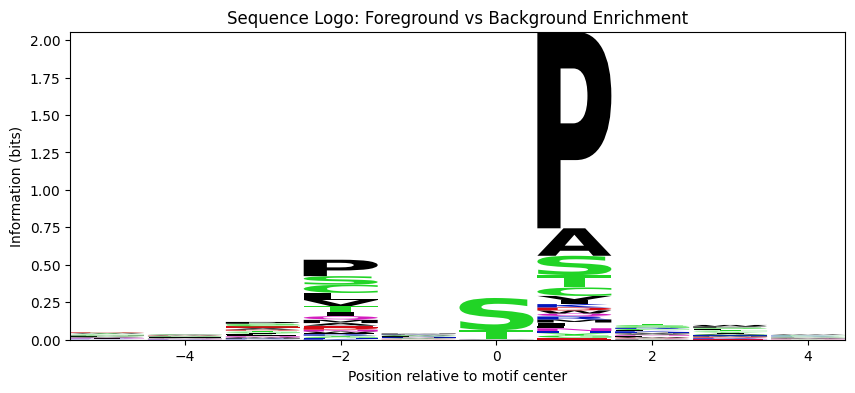

In [21]:
import logomaker
import matplotlib.pyplot as plt

# Helper to convert a list of sequences into a counts matrix
def sequences_to_counts(sequences):
    # Extract position columns
    length = len(sequences[0])
    amino_acids = "ACDEFGHIKLMNPQRSTVWY"
    counts_df = pd.DataFrame(0, index=range(length), columns=list(amino_acids))

    for seq in sequences:
        for i, char in enumerate(seq):
            if char in counts_df.columns:
                counts_df.loc[i, char] += 1
    return counts_df

# 1. Prepare data
fg_sequences = fg_dat['sequence'].tolist()
bg_sequences = bg_dat['bg'].tolist()

fg_counts = sequences_to_counts(fg_sequences)
bg_counts = sequences_to_counts(bg_sequences)

# 2. Create the Probability matrices
fg_prob = logomaker.transform_matrix(fg_counts, from_type='counts', to_type='probability')
bg_prob = logomaker.transform_matrix(bg_counts, from_type='counts', to_type='probability')

# 3. Calculate Information Content (Enrichment)
# FIX: Added from_type='probability' so logomaker knows the input format
logo_df = logomaker.transform_matrix(fg_prob,
                                    from_type='probability',
                                    background=bg_prob,
                                    to_type='information')
logo_df.index = range(-5, 5)

# 4. Plot
fig, ax = plt.subplots(figsize=(10, 4))
logo = logomaker.Logo(logo_df, ax=ax, color_scheme='weblogo_protein')

ax.set_ylabel('Information (bits)')
ax.set_xlabel('Position relative to motif center')
ax.set_title('Sequence Logo: Foreground vs Background Enrichment')
plt.show()

## Summary

- **`fg.csv`**: Foreground dataset — one column with compiled 10-mer sequences. Each sequence's amino acids at each position match the input probabilities scaled to 1000 samples.
- **`fg_full.csv`**: Same foreground data but with all position columns (-5 to +4) included for inspection.
- **`bg.csv`**: Background dataset — 5000 random 10-mer sequences with position 0 constrained to S/T.

These files can be used for downstream motif visualization (e.g., sequence logos, position weight matrices, etc.).

---

> **Note**: The source modules (`biology.py`, `csv_to_fgbg.py`, `random_input.py`) are fetched fresh from GitHub each time the setup cells are re-run. This keeps the notebook automatically in sync with the repository.